## Appendix: Rubric mapping (for TAs / instructors)

| Rubric section | Where it is covered in *this* notebook |
|----------------|----------------------------------------|
| 1. Problem Framing | **## 1. Problem Framing** (after the title / TA instructions cells) |
| 2. Data Acquisition, Preparation & Exploration | **## 2. Data Acquisition...** and following load / feature / exploration code |
| 3. Modeling & Feature Selection | **## 3. Modeling & Feature Selection** + preprocessing, model comparison, tuning |
| 4. Evaluation & Interpretation | **## 4. Evaluation & Interpretation** + thresholding, ROC/PR, confusion matrix, tiers |
| 5. Causal and Relationship Analysis | **## 5. Causal and Relationship Analysis** + interpretation narrative |
| 6. Deployment Notes | **## 6. Deployment Notes** + artifact export and live service integration |

Graded narrative is in the **## 1–6** section headings; this table is only a navigation aid.

### From exploration to modeling inputs
After exploration, we summarize **feature engineering choices** (static context + 30-day incident/education aggregates), then enter **Section 3** for the **leakage-safe matrix**, **preprocessor**, and **classifier comparison**.


# Resident Transfer Risk Pipeline (IS 455)

> This notebook follows the same **six-section** rubric structure as `donation_prediction.ipynb`: each section should be specific, evidence-based, and deployment-linked.

## TA run instructions
- Run this notebook with working directory set to **`ml-pipelines/`**.
- Use **Kernel → Restart & Run All** to reproduce results and refresh artifacts under `ml-pipelines/artifacts/`.
- Training uses CSVs under **`datasets/`**; production scoring in **ml-service** mirrors the same **30-day post-enrollment** feature logic against PostgreSQL.

**Primary question:** Which residents are at risk of being **Transferred** instead of **Closed** (as of a fixed early case window)?  
**Operational question:** Who should staff **reach out to first** for proactive support?


## 1. Problem Framing

### Business problem
Case managers and program leadership need an **early warning** of which resident cases may **transfer** to another placement rather than **close** successfully from Lighthouse’s perspective. Transfers are not always “failure,” but they often signal **instability, unmet needs, or coordination strain**. Prioritizing outreach can improve support timing.

### Who cares and why it matters
- **Social workers / case managers:** finite time; need a ranked list and interpretable risk tiers.
- **Program leadership:** workload planning, safehouse coordination, and quality review.
- **Admin dashboard users:** the shipped **“Residents to Reach Out”** card summarizes risk tiers and example residents for weekly triage.

### Predictive vs explanatory (textbook framing)
This notebook is **predictive-first**: we estimate **probability of transfer vs closure** among cases with a **known final outcome**, using only information that would have been available **within the first 30 days after enrollment**. We still interpret feature importance for **plausibility**, but we **do not** claim causal effects of interventions.

### Outcome definition and modeling population
- We restrict to residents whose **`case_status`** is **`Closed`** or **`Transferred`** (final outcomes known).
- **Target:** `y = 1` if **Transferred**, `0` if **Closed**.
- We **exclude Active** cases from training because the final outcome is unknown—this matches a **retrospective learning** setup; **live scoring** in ml-service applies the same feature recipe to **Active** residents for the dashboard.

### Success criteria
- **Discrimination:** holdout **ROC-AUC** and **average precision (PR-AUC)** on imbalanced data.
- **Operations:** a **threshold** that meets a minimum **recall** on transferred cases (configurable), trading off precision vs workload.
- **Deployment:** a single **`sklearn` `Pipeline`** (preprocess + classifier) saved as **`resident_transfer_risk_model.joblib`**, loadable by **ml-service** without retraining in the request path.


In [1]:
# Setup: imports, reproducibility, and paths
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

SEED = 42
np.random.seed(SEED)

ROOT = Path.cwd().resolve().parent
DATA_DIR = ROOT / 'datasets'
ARTIFACT_DIR = Path.cwd() / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('Data dir:', DATA_DIR)
print('Artifact dir:', ARTIFACT_DIR)


Data dir: /Users/lukemarchant/Desktop/IntextW2026/datasets
Artifact dir: /Users/lukemarchant/Desktop/IntextW2026/ml-pipelines/artifacts


## 2. Data Acquisition, Preparation & Exploration

### Data sources used
- **`datasets/residents.csv`** — case context, demographics, risk fields, enrollment dates, and **final `case_status`**.
- **`datasets/incident_reports.csv`** — incident timing, severity, resolution, follow-up flags (joined on **`resident_id`**).
- **`datasets/education_records.csv`** — attendance and progress by record date (joined on **`resident_id`**).

### Join logic and keys
- **Primary key:** `resident_id` across all three tables.
- **Left joins** after aggregating incidents and education to **resident level** preserve the outcome cohort defined on `residents`.

### Time window and leakage control (core design choice)
- **Prediction cutoff:** `date_enrolled + 30 days` (see `PREDICTION_WINDOW_DAYS`).
- **Incidents and education records** are only counted if their dates fall in **`[date_enrolled, prediction_cutoff_date]`** inclusive.
- This mirrors what a decision-maker could know **one month into enrollment** and prevents using **post-window** events as predictors.

### Exploration in this section
The code below loads CSVs, parses dates, builds the merged modeling frame, and reports **missingness**, **class balance**, and simple **distributional / correlation** views. Use outputs as evidence of data quality and whether early-window signals carry signal.


In [2]:
# Load datasets
res = pd.read_csv(DATA_DIR / 'residents.csv')
inc = pd.read_csv(DATA_DIR / 'incident_reports.csv')
edu = pd.read_csv(DATA_DIR / 'education_records.csv')

print('residents:', res.shape)
print('incident_reports:', inc.shape)
print('education_records:', edu.shape)

for c in ['date_of_admission', 'date_enrolled', 'date_closed', 'created_at']:
    if c in res.columns:
        res[c] = pd.to_datetime(res[c], errors='coerce')

for c in ['incident_date', 'resolution_date']:
    if c in inc.columns:
        inc[c] = pd.to_datetime(inc[c], errors='coerce')

if 'record_date' in edu.columns:
    edu['record_date'] = pd.to_datetime(edu['record_date'], errors='coerce')

residents: (60, 49)
incident_reports: (100, 12)
education_records: (534, 10)


In [3]:
# Predictive feature engineering: only information available by day-30 after enrollment
PREDICTION_WINDOW_DAYS = 30
severity_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}

# Base residents filtered to final outcomes
base = res[res['case_status'].isin(['Closed', 'Transferred'])].copy()
base['target_transferred'] = (base['case_status'] == 'Transferred').astype(int)
base['prediction_cutoff_date'] = base['date_enrolled'] + pd.to_timedelta(PREDICTION_WINDOW_DAYS, unit='D')

# Build incident features restricted to first 30 days post enrollment
inc2 = inc.copy()
inc2['severity_num'] = inc2['severity'].map(severity_map)
inc2['resolved_num'] = inc2['resolved'].astype(str).str.lower().map({'true': 1, 'false': 0})
inc2['follow_up_num'] = inc2['follow_up_required'].astype(str).str.lower().map({'true': 1, 'false': 0})

inc30 = base[['resident_id', 'date_enrolled', 'prediction_cutoff_date']].merge(
    inc2, on='resident_id', how='left'
)
inc30 = inc30[
    inc30['incident_date'].notna()
    & inc30['date_enrolled'].notna()
    & (inc30['incident_date'] >= inc30['date_enrolled'])
    & (inc30['incident_date'] <= inc30['prediction_cutoff_date'])
].copy()
inc30['unresolved_high'] = ((inc30['resolved_num'] == 0) & (inc30['severity_num'] >= 3)).astype(int)

inc_agg = inc30.groupby('resident_id', as_index=False).agg(
    incident_count_30d=('incident_id', 'count'),
    incident_severity_mean_30d=('severity_num', 'mean'),
    incident_severity_max_30d=('severity_num', 'max'),
    unresolved_ratio_30d=('resolved_num', lambda s: 1 - s.fillna(0).mean()),
    unresolved_high_count_30d=('unresolved_high', 'sum'),
    follow_up_ratio_30d=('follow_up_num', 'mean'),
)

# Build education features restricted to first 30 days post enrollment
edu30 = base[['resident_id', 'date_enrolled', 'prediction_cutoff_date']].merge(
    edu, on='resident_id', how='left'
)
edu30 = edu30[
    edu30['record_date'].notna()
    & edu30['date_enrolled'].notna()
    & (edu30['record_date'] >= edu30['date_enrolled'])
    & (edu30['record_date'] <= edu30['prediction_cutoff_date'])
].copy()

edu_agg = edu30.sort_values(['resident_id', 'record_date']).groupby('resident_id', as_index=False).agg(
    edu_records_30d=('education_record_id', 'count'),
    attendance_mean_30d=('attendance_rate', 'mean'),
    attendance_last_30d=('attendance_rate', 'last'),
    progress_mean_30d=('progress_percent', 'mean'),
    progress_last_30d=('progress_percent', 'last'),
)
edu_agg['progress_delta_30d'] = edu_agg['progress_last_30d'] - edu_agg['progress_mean_30d']
edu_agg['attendance_delta_30d'] = edu_agg['attendance_last_30d'] - edu_agg['attendance_mean_30d']

# Merge logic: left joins keep the resident outcome cohort and attach early-window signals
joined = (
    base
    .merge(inc_agg, on='resident_id', how='left')
    .merge(edu_agg, on='resident_id', how='left')
)

print('Modeling population shape:', joined.shape)
print('Transferred rate:', round(joined['target_transferred'].mean(), 3))
print('Residents with 30-day incident signals:', joined['incident_count_30d'].notna().sum())
print('Residents with 30-day education signals:', joined['edu_records_30d'].notna().sum())

Modeling population shape: (30, 64)
Transferred rate: 0.367
Residents with 30-day incident signals: 1
Residents with 30-day education signals: 30


In [4]:
# Exploratory checks: missingness, distributions, correlation snapshot
missing = joined.isna().mean().sort_values(ascending=False).head(20)
print('Top missingness (%):')
display((missing * 100).round(1).to_frame('missing_pct'))

print('\nOutcome counts:')
print(joined['case_status'].value_counts())

num_cols_preview = [
    'incident_count', 'incident_severity_mean', 'unresolved_ratio',
    'attendance_mean', 'progress_mean', 'length_of_stay'
]
for c in num_cols_preview:
    if c in joined.columns:
        print(f"{c}:\n", joined[c].describe(), "\n")

corr_cols = [c for c in ['target_transferred','incident_count','incident_severity_mean','unresolved_ratio','attendance_mean','progress_mean','progress_delta'] if c in joined.columns]
if len(corr_cols) >= 3:
    corr = joined[corr_cols].corr(numeric_only=True)
    print('Correlation matrix (numeric subset):')
    display(corr)

# Simple outlier view for incident_count
if 'incident_count' in joined.columns:
    plt.figure(figsize=(6, 3))
    plt.boxplot(joined['incident_count'].fillna(0))
    plt.title('Incident count outlier check')
    plt.show()

Top missingness (%):


,missing_pct
notes_restricted,100.0
follow_up_ratio_30d,96.7
incident_count_30d,96.7
incident_severity_mean_30d,96.7
incident_severity_max_30d,96.7
unresolved_ratio_30d,96.7
unresolved_high_count_30d,96.7
special_needs_diagnosis,93.3
pwd_type,90.0
date_colb_obtained,43.3



Outcome counts:
case_status
Closed         19
Transferred    11
Name: count, dtype: int64
length_of_stay:
 count                   30
unique                  17
top       0 Years 9 months
freq                     4
Name: length_of_stay, dtype: object 



### Feature engineering decisions
- Keep resident-level static context known early in the case lifecycle.
- Add cross-table behavior features from incidents in the first 30 days.
- Add education momentum features from records in the first 30 days.
- Exclude direct identifiers (`resident_id`, case codes) to prevent memorization.
- Exclude leakage fields unavailable at prediction time (`date_closed`, `days_enrolled_to_closed`, post-outcome statuses).

This is implemented as a reproducible sklearn `Pipeline` with `ColumnTransformer`, so transformations are identical in train/test and future scoring.


## 3. Modeling & Feature Selection

### Modeling matrix, leakage audit, and split
The next code cell **drops outcome-adjacent and identifier columns**, prints a small **leakage audit** table, and builds `X` / `y` for **`target_transferred`**. It then applies a **time-respecting split** on **`date_enrolled`** when possible (train on earlier enrollments, test on later), with a **stratified random fallback** when the temporal holdout is too small or single-class. A single **`ColumnTransformer`** defines **numeric** (median impute + scale) and **categorical** (mode impute + one-hot with `handle_unknown='ignore'`) branches so training, evaluation, and **joblib export** stay aligned.

### Model candidates and selection logic
We compare **logistic regression**, **random forest**, and **gradient boosting** with **5-fold stratified CV** on the training split, scoring primarily by **average precision** (PR-AUC) because the positive class can be minority. The best family may be refined with **`GridSearchCV`** on depth / leaves / estimators.

### Feature selection stance
We do **not** run aggressive univariate filtering here: the leakage audit and **early 30-day window** are the main guards. **Importance / coefficient** summaries below support **face-validity**, not causal claims.



In [5]:
# Build model-ready matrix with leakage audit and time-based split
leakage_cols = [
    'target_transferred', 'case_status', 'resident_id', 'case_control_no', 'internal_code',
    'date_closed', 'days_enrolled_to_closed', 'notes_restricted', 'created_at',
    'reintegration_status'
]

leakage_audit = pd.DataFrame([
    {'feature': 'date_closed', 'keep_for_prediction': False, 'reason': 'Known only at closure/transfer outcome'},
    {'feature': 'days_enrolled_to_closed', 'keep_for_prediction': False, 'reason': 'Direct outcome timing leakage'},
    {'feature': 'reintegration_status', 'keep_for_prediction': False, 'reason': 'Can be updated late in case lifecycle'},
    {'feature': 'incident_count_30d', 'keep_for_prediction': True, 'reason': 'Observable by day-30 prediction cutoff'},
    {'feature': 'progress_delta_30d', 'keep_for_prediction': True, 'reason': 'Built only from early education records'},
])
display(leakage_audit)

X = joined.drop(columns=[c for c in leakage_cols if c in joined.columns], errors='ignore')
y = joined['target_transferred']

# Time anchor for forward split
if 'date_enrolled' in joined.columns:
    split_time = joined['date_enrolled'].quantile(0.75)
    train_mask = joined['date_enrolled'] <= split_time
    test_mask = joined['date_enrolled'] > split_time
else:
    # Fallback if date_enrolled is unavailable
    train_mask = pd.Series([True] * len(joined))
    test_mask = pd.Series([False] * len(joined))

# Keep date columns only as engineered durations if needed; drop raw datetimes
for c in X.columns:
    if str(X[c].dtype).startswith('datetime64'):
        X = X.drop(columns=[c])

numeric_features = X.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features),
    ]
)

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

# Safety fallback if temporal split is too small/imbalanced
if len(X_test) < 5 or y_test.nunique() < 2 or y_train.nunique() < 2:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=SEED, stratify=y
    )
    split_note = 'Fallback to stratified random split (insufficient temporal holdout).'
else:
    split_note = f'Temporal split at enrollment date <= {split_time.date()} for train, later for test.'

print(split_note)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Transferred rate (train/test):', round(y_train.mean(), 3), round(y_test.mean(), 3))

,feature,keep_for_prediction,reason
0,date_closed,False,Known only at closure/transfer outcome
1,days_enrolled_to_closed,False,Direct outcome timing leakage
2,reintegration_status,False,Can be updated late in case lifecycle
3,incident_count_30d,True,Observable by day-30 prediction cutoff
4,progress_delta_30d,True,Built only from early education records


Temporal split at enrollment date <= 2024-07-27 for train, later for test.
Train shape: (22, 52) Test shape: (8, 52)
Transferred rate (train/test): 0.318 0.5


In [6]:
models = {
    'logistic': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=SEED),
    'random_forest': RandomForestClassifier(n_estimators=400, random_state=SEED, class_weight='balanced'),
    'gradient_boosting': GradientBoostingClassifier(random_state=SEED),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
comparison = []
trained = {}

for name, clf in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', clf)])
    auc_pr = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision').mean()
    f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1').mean()
    comparison.append({'model': name, 'cv_avg_precision': auc_pr, 'cv_f1': f1})
    pipe.fit(X_train, y_train)
    trained[name] = pipe

comparison_df = pd.DataFrame(comparison).sort_values('cv_avg_precision', ascending=False)
display(comparison_df)

best_name = comparison_df.iloc[0]['model']
best_model = trained[best_name]
print('Selected model:', best_name)

# Hyperparameter tuning for random forest (if selected)
if best_name == 'random_forest':
    param_grid = {
        'model__n_estimators': [200, 400, 700],
        'model__max_depth': [None, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
    }
    grid = GridSearchCV(
        best_model,
        param_grid=param_grid,
        scoring='average_precision',
        cv=cv,
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    print('Best RF params:', grid.best_params_)

trained['selected'] = best_model

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['special_needs_diagnosis']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['special_needs_diagnosis']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['incident_count_30d' 'incident_severity_mean_30d'
 'incident_severity_max_30d' 'unresolved_ratio_30d'
 'unresolved_high_count_30d' 'follow_up_ratio_30d']. At least one non-missing value is needed for imputation with strategy='

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['special_needs_diagnosis']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['special_needs_diagnosis']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['incident_count_30d' 'incident_severity_mean_30d'
 'incident_severity_max_30d' 'unresolved_ratio_30d'
 'unresolved_high_count_30d' 'follow_up_ratio_30d']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['incident_count_30d' 'incident_severity_mean_30d'
 'incident_severity_max_30d' 'unresolved_ratio_30d'
 'unresolved_high_count_30d' 'follow_up_ratio_30d']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


...

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['incident_count_30d' 'incident_severity_mean_30d'
 'incident_severity_max_30d' 'unresolved_ratio_30d'
 'unresolved_high_count_30d' 'follow_up_ratio_30d']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['special_needs_diagnosis']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['special_needs_diagnosis']. At least one non-missing value is needed for imputation with strategy='most_fr

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['incident_count_30d' 'incident_severity_mean_30d'
 'incident_severity_max_30d' 'unresolved_ratio_30d'
 'unresolved_high_count_30d' 'follow_up_ratio_30d']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['special_needs_diagnosis']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['incident_count_30d' 'incident_severity_mean_30d'
 'incident_severity_max_30d' 'unresolved_ratio_30d'
 'un

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['special_needs_diagnosis']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['incident_count_30d' 'incident_severity_mean_30d'
 'incident_severity_max_30d' 'unresolved_ratio_30d'
 'unresolved_high_count_30d' 'follow_up_ratio_30d']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['incident_count_30d' 'incident_severity_mean_30d'
 'incident_severity_max_30d' 'unresolved_ratio_30d'
 'un

Best RF params: {'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['special_needs_diagnosis']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['incident_count_30d' 'incident_severity_mean_30d'
 'incident_severity_max_30d' 'unresolved_ratio_30d'
 'unresolved_high_count_30d' 'follow_up_ratio_30d']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [7]:
# Feature selection / importance view
selected_model = trained['selected']

proba = selected_model.predict_proba(X_test)[:, 1]
pred_default = (proba >= 0.5).astype(int)

print('Default threshold classification report:')
print(classification_report(y_test, pred_default, digits=3))

# Business-weighted threshold: favor recall for transferred residents
prec, rec, thr = precision_recall_curve(y_test, proba)
valid_idx = np.where(rec[:-1] >= 0.75)[0]
threshold = float(thr[valid_idx[0]]) if len(valid_idx) else 0.5
pred_operational = (proba >= threshold).astype(int)

print('Operational threshold:', round(threshold, 3))
print('Precision:', round(precision_score(y_test, pred_operational, zero_division=0), 3))
print('Recall:', round(recall_score(y_test, pred_operational, zero_division=0), 3))
print('F1:', round(f1_score(y_test, pred_operational, zero_division=0), 3))

if hasattr(selected_model.named_steps['model'], 'feature_importances_'):
    feat_names = selected_model.named_steps['prep'].get_feature_names_out()
    importances = selected_model.named_steps['model'].feature_importances_
    fi = pd.DataFrame({'feature': feat_names, 'importance': importances}).sort_values('importance', ascending=False)
    display(fi.head(20))
else:
    print('Selected model has no native tree importances; use coefficients or permutation importance.')

Default threshold classification report:
              precision    recall  f1-score   support

           0      0.571     1.000     0.727         4
           1      1.000     0.250     0.400         4

    accuracy                          0.625         8
   macro avg      0.786     0.625     0.564         8
weighted avg      0.786     0.625     0.564         8

Operational threshold: 0.38
Precision: 0.5
Recall: 1.0
F1: 0.667


,feature,importance
0,num__safehouse_id,0.107954
25,num__attendance_mean_30d,0.096155
28,num__progress_last_30d,0.073327
170,cat__date_colb_obtained_2023-06-21,0.072247
232,cat__current_risk_level_Low,0.056609
200,cat__initial_case_assessment_For Independent L...,0.048140
27,num__progress_mean_30d,0.048007
26,num__attendance_last_30d,0.044572
53,cat__birth_status_Marital,0.042086
54,cat__birth_status_Non-Marital,0.037982


## 4. Evaluation & Interpretation

### Metrics reported
- **Classification:** precision, recall, F1 at a **default 0.5** threshold and at an **operational threshold** chosen from the precision–recall curve (e.g., target recall ≥ 0.75 on transferred cases).
- **Ranking quality:** **ROC-AUC** and **PR-AUC (average precision)** on the holdout set.
- **Confusion matrix** at the operational threshold for auditability.

### Risk tiers for operations
Probabilities are binned into **Monitor / Medium / High** tiers for the dashboard (production uses fixed probability bins; the notebook may align tier cut points with the chosen threshold—see code comments in-cell).

### Business interpretation
- **High recall** reduces **missed** at-risk residents (fewer false negatives) but increases **false alarms** and staff workload.
- **High precision** reduces unnecessary outreach but risks missing vulnerable cases.
- In many child-welfare–style workflows, **false negatives are treated as more costly** than false positives; the threshold section encodes that preference explicitly—still require **human review** for high-stakes decisions.


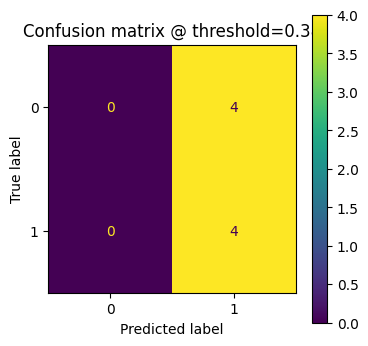

ROC-AUC: 1.0
PR-AUC (avg precision): 1.0


,case_control_no,pred_transfer_prob,risk_tier,actual_transferred
4,C7521,0.523912,Medium,1
0,C0855,0.454657,Medium,1
3,C9903,0.446885,Medium,1
2,C6505,0.442396,Medium,1
7,C5053,0.423643,Medium,0
5,C2281,0.414251,Medium,0
1,C2853,0.389438,Medium,0
6,C3620,0.379783,Monitor,0


Saved: /Users/lukemarchant/Desktop/IntextW2026/ml-pipelines/artifacts/resident_transfer_risk_scored_sample.csv


In [8]:
# Confusion matrix + risk tier outputs for operations
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred_operational, ax=ax)
ax.set_title(f'Confusion matrix @ threshold={threshold:.2f}')
plt.show()

print('ROC-AUC:', round(roc_auc_score(y_test, proba), 3))
print('PR-AUC (avg precision):', round(average_precision_score(y_test, proba), 3))

scored = X_test.copy()
scored['actual_transferred'] = y_test.values
scored['pred_transfer_prob'] = proba
scored['risk_tier'] = pd.cut(
    scored['pred_transfer_prob'],
    bins=[-0.001, threshold, 0.75, 1.0],
    labels=['Monitor', 'Medium', 'High']
)

# Attach resident identifiers for dashboard outreach list.
resident_meta_cols = [
    'resident_id', 'case_control_no', 'internal_code', 'assigned_social_worker', 'safehouse_id'
]
resident_meta = joined.loc[X_test.index, [c for c in resident_meta_cols if c in joined.columns]].copy()
resident_meta = resident_meta.reset_index(drop=True)
scored = scored.reset_index(drop=True)
scored = pd.concat([resident_meta, scored], axis=1)

display(scored[['case_control_no', 'pred_transfer_prob', 'risk_tier', 'actual_transferred']].sort_values('pred_transfer_prob', ascending=False).head(15))

scored[['resident_id', 'case_control_no', 'internal_code', 'assigned_social_worker', 'safehouse_id', 'pred_transfer_prob', 'risk_tier', 'actual_transferred']].to_csv(
    ARTIFACT_DIR / 'resident_transfer_risk_scored_sample.csv', index=False
)
print('Saved:', ARTIFACT_DIR / 'resident_transfer_risk_scored_sample.csv')

In [9]:
# Persist artifacts for reproducibility and deployment handoff
import joblib

joined.to_csv(ARTIFACT_DIR / 'resident_transfer_joined_dataset.csv', index=False)
joblib.dump(selected_model, ARTIFACT_DIR / 'resident_transfer_risk_model.joblib')

metrics_payload = {
    'selected_model': best_name,
    'threshold': float(threshold),
    'roc_auc': float(roc_auc_score(y_test, proba)),
    'avg_precision': float(average_precision_score(y_test, proba)),
    'precision_at_threshold': float(precision_score(y_test, pred_operational, zero_division=0)),
    'recall_at_threshold': float(recall_score(y_test, pred_operational, zero_division=0)),
    'f1_at_threshold': float(f1_score(y_test, pred_operational, zero_division=0)),
}

pd.DataFrame([metrics_payload]).to_csv(ARTIFACT_DIR / 'resident_transfer_risk_metrics.csv', index=False)
print('Saved artifacts to:', ARTIFACT_DIR)

Saved artifacts to: /Users/lukemarchant/Desktop/IntextW2026/ml-pipelines/artifacts


## 5. Causal and Relationship Analysis

### What relationships appear strongest?
Interpret grouped signals (from feature importances or coefficients):
1. **Incident burden** — counts, mean/max severity, unresolved high-severity incidents, follow-up ratios.
2. **Education momentum** — attendance/progress means, last vs mean (delta), recorded only in the first 30 days.
3. **Case context** — referral source, risk levels, case category, safehouse, and static intake fields.

### Do these relationships make theoretical sense?
Often **yes, as patterns**: higher unresolved serious incidents and declining engagement can coincide with cases that later transfer; however, they may also **proxy latent severity** or **placement-specific practices**.

### Correlation vs causation
This pipeline is **predictive**. Importance weights describe **associations** that improve ranking, not proof that changing one input (e.g., “add tutoring”) **causes** a lower transfer probability. Confounding is likely (worker assignment, safehouse, referral channel, unobserved trauma history).

### Defensible vs indefensible claims
- **Defensible:** early-window incident and education structure helps **rank** cases for triage; monitoring is justified when calibrated with human judgment.
- **Not defensible without further design:** causal statements about specific interventions or blame assigned from the model score alone.

### Practical use despite limits
Stable predictive patterns still support **workflow prioritization** when paired with **supervision, appeals, and periodic fairness / drift checks**.


## 6. Deployment Notes

### Artifacts produced (under `ml-pipelines/artifacts/`)
- **`resident_transfer_risk_model.joblib`** — fitted `Pipeline` (preprocessing + classifier) consumed by ml-service.
- **`resident_transfer_risk_metrics.csv`** — one row with selected model name, operational threshold, and holdout metrics.
- **`resident_transfer_risk_scored_sample.csv`** — example scored rows with identifiers for UI / QA (optional for grading).
- **`resident_transfer_joined_dataset.csv`** — joined training frame snapshot for reproducibility.

### Live integration (as implemented in this repo)
- **Feature engineering aligned with this notebook:** `ml-service/app/resident_transfer_risk.py` (SQL + pandas mirrors the 30-day window; active residents only in production).
- **HTTP endpoint:** `GET /residents/transfer-risk-summary` in `ml-service/app/main.py`.
- **.NET proxy:** `ResidentsTransferRiskAnalyticsApiController` → `GET /api/admin/analytics/residents-transfer-risk`.
- **Admin UI:** `frontend/src/pages/AdminDashboard.tsx` — **“Residents to Reach Out”** chart and list.

### Environment and performance (production)
- ml-service needs the same **PostgreSQL** connection pattern as other live endpoints (`SOCIAL_MEDIA_DB_URL` or `ConnectionStrings__DefaultConnection`).
- **scikit-learn version** used to **train and dump** the model should match **`ml-service/requirements.txt`** (currently pinned for pickle compatibility).
- Optional: **`RESIDENT_TRANSFER_RISK_CACHE_TTL_SECONDS`** on the ML service to cache JSON responses briefly.

### Governance
- **Retrain** on schedule or when drift is detected (referral mix, safehouse mix, policy changes).
- Track **subgroup** error rates where sample size allows; keep **human-in-the-loop** for removal/transfer decisions.


### Textbook crosswalk (Chapters 0–17) used in this notebook

| Chapter group | Principle | Where applied |
|---------------|-----------|---------------|
| Ch 0–1 | End-to-end pipeline and business framing | Sections 1 and 6 |
| Ch 2–3 | Data understanding and quality | Missingness, outcomes, distributions |
| Ch 4–5 | Preparation and leakage control | 30-day window, leakage audit, temporal split |
| Ch 7 | Reproducible `sklearn` `Pipeline` | `ColumnTransformer` + estimators |
| Ch 8 | Automation mindset | Single top-to-bottom notebook + saved artifacts |
| Ch 9–11 | Classification metrics and decision thresholds | PR curve, recall-oriented threshold, confusion matrix |
| Ch later | Responsible use of prediction | Section 5 — association vs causation, human review |
